In [ ]:
import numpy as np
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import RobustScaler
import random

# -------------- Parameters -----------------------
time_steps = 100000

class plot():
    def plotxy(
        series_list,
        index=None,
        title="",
        xlabel="time stamps",
        ylabel="",
        figsize=(14, 7),
        axhline=None,
        show_legend=True,
        disable_scietific_format = False,
    ):
        plt.figure(figsize=figsize), 
        
        for series  in series_list: 
            y_vals = np.asarray(series["y"])
            if index is not None:
                y_vals = y_vals[:index]
                
            plt.plot(
            y_vals,
            label=series.get("label"),
            color=series.get("color", "#0275D8"),
            linewidth=series.get("linewidth", 1.5),
            alpha=series.get("alpha", 1.0),
            linestyle=series.get("linestyle", "-"),)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        if disable_scietific_format == True:
            plt.ticklabel_format(style="plain", useOffset=False, axis="both")
        if axhline is not None:
            plt.axhline(axhline, color="black", linestyle="--", alpha=0.5)

        if show_legend:
            plt.legend()
        plt.show()
        
        
        
    def plot_spikes(
        series_list,
        index=None,
        value = 1.0,
        title="",
        xlabel="time stamps",
        ylabel="",
        figsize=(14, 7),
        axhline=None,
        show_legend=True,
        disable_scietific_format=False,
        
    ):
        plt.figure(figsize=figsize), 
        
        for series in series_list:
            
            y_spikes = np.asarray(series["y"])
            if index is not None:
                y_spikes = y_spikes[:index]
            
            spike_point = np.atleast_1d(y_spikes)
            spike_point = np.where(y_spikes == value)[0]
            plt.vlines(
                spike_point,
                ymax=series.get("ymax", 0.5),
                ymin=series.get("ymin", 1.5),
                label=series.get("label"),
                color=series.get("color", "red"),
                linewidth=series.get("linewidth", 1.5),
                alpha=series.get("alpha", 1.0),
                linestyle=series.get("linestyle", "-"),
           )
            
        plt.title(title)
        plt.xlabel(xlabel)
        plt.ylabel(ylabel)
        
        if disable_scietific_format == True:
            plt.ticklabel_format(style="plain", useOffset=False, axis="both")
        if axhline is not None:
            plt.axhline(axhline, color="black", linestyle="--", alpha=0.5)

        if show_legend:
            plt.legend()
        plt.show()
        
        
plot_xy = plot.plotxy
plot_spike  = plot.plot_spikes

In [4]:
# Load the data/seperates the features and labels 
input_file = "data/published/BenchmarkDatasets/BenchmarkDatasets/BenchmarkDatasets/NoAuction/NoAuction_MinMax/NoAuction_MinMax_Training/Train_Dst_NoAuction_MinMax_CF_1.txt"
output_dir = "processed_data"
os.makedirs(output_dir, exist_ok=True)


# Load the data matrix
raw_data = np.loadtxt(input_file)
print(f"Original shape: {raw_data.shape}") # 149 by X columns

# Extract Features (First 144 rows) and Transpose to get (Time_Steps, Features)
features = raw_data[:144, :].T

# Extract Labels (Last 5 rows represent different prediction horizons)
labels = raw_data[146, :].T - 1 

print(f"Processed Features shape: {features.shape}") # (X, 144)
print(f"Processed Labels shape: {labels.shape}")     # (X,)
 
np.save(os.path.join(output_dir, "train_features_1.npy"), features)
np.save(os.path.join(output_dir, "train_labels_1.npy"), labels)
print("Success")

Original shape: (149, 39512)
Processed Features shape: (39512, 144)
Processed Labels shape: (39512,)
Success


[0.60146038 0.60146038 0.60123974 ... 0.99226059 0.99203866 0.99203866]


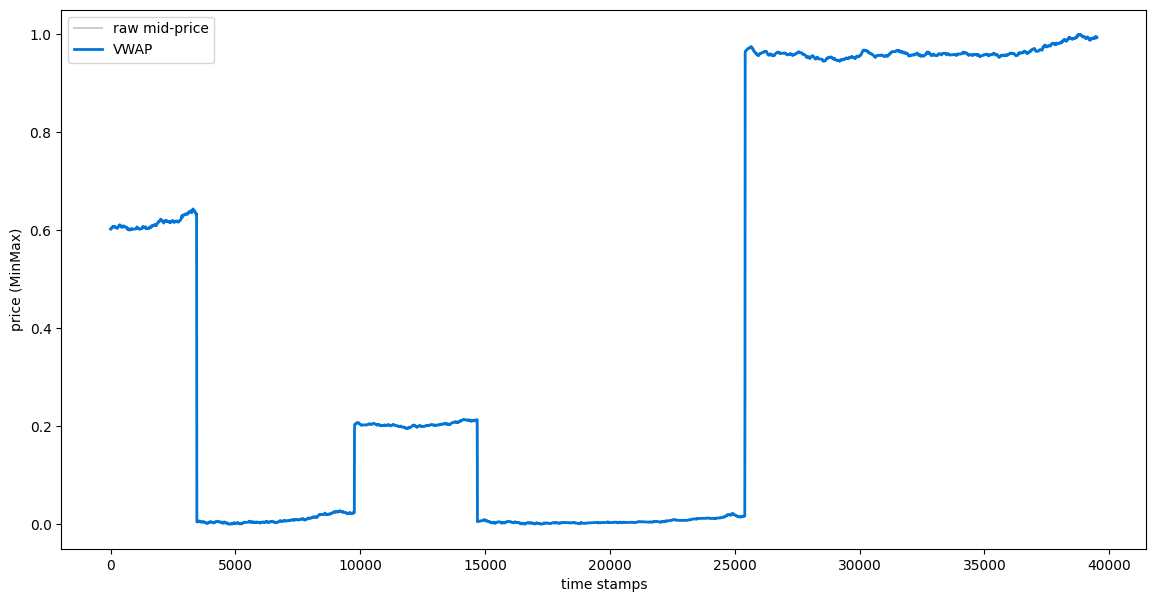

In [27]:
# VWAP on the Mid-price to transform market "zig-zag" into a clean compatible for our SNN 
data = np.loadtxt(input_file)

ask_price = data[0, :]
ask_volume = data[1, :]
bid_price = data[2, :]
bid_volume = data[3, :]

mid_price = (ask_price + bid_price) / 2
# total liquidity
total_volume = ask_volume + bid_volume

# window size (n = 10)
window_size = 10
# Price * Volume for VWAP
pv = mid_price * total_volume

# Rolling sum for the VWAP numerator and denominator
def rolling_sum(a, n=10):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]

vwap_numerator = rolling_sum(pv, window_size)
vwap_denominator = rolling_sum(total_volume, window_size)

# Final VWAP signal
vwap = vwap_numerator / vwap_denominator

print(mid_price)

# Note: vwap is shorter by (window_size - 1)
plot_xy(
    series_list=[
        {"y": mid_price, "label": "raw mid-price", "color": "gray", "alpha": 0.4},
        {"y": vwap, "label": "VWAP", "color": "#0275D8", "linewidth": 2},
    ],
    index=time_steps,
    title="Mid-Price vs VWAP",
    ylabel="price (MinMax)",
)

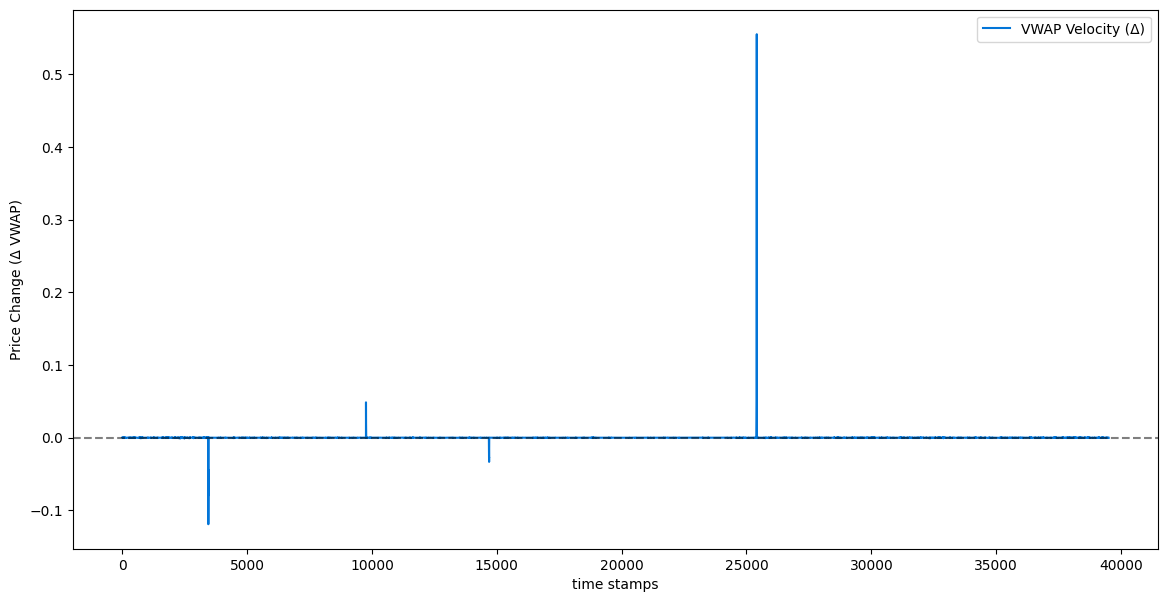

In [28]:
# np.diff shortened vwap by 1 hope that wont cause some pretty big problem later
vwap_diff = np.diff(vwap)
# Align labels with the shortened diff array for future training (later)
aligned_labels = labels[10:]
plot_xy(
    series_list=[
        {"y": vwap_diff, "label": "VWAP Velocity (Δ)", "color": "#0275D8", "linewidth": 1.5},
    ],
    index=time_steps,
    title="Differenced VWAP (Momentum)",
    ylabel="Price Change (Δ VWAP)",
    axhline=0,
 )         

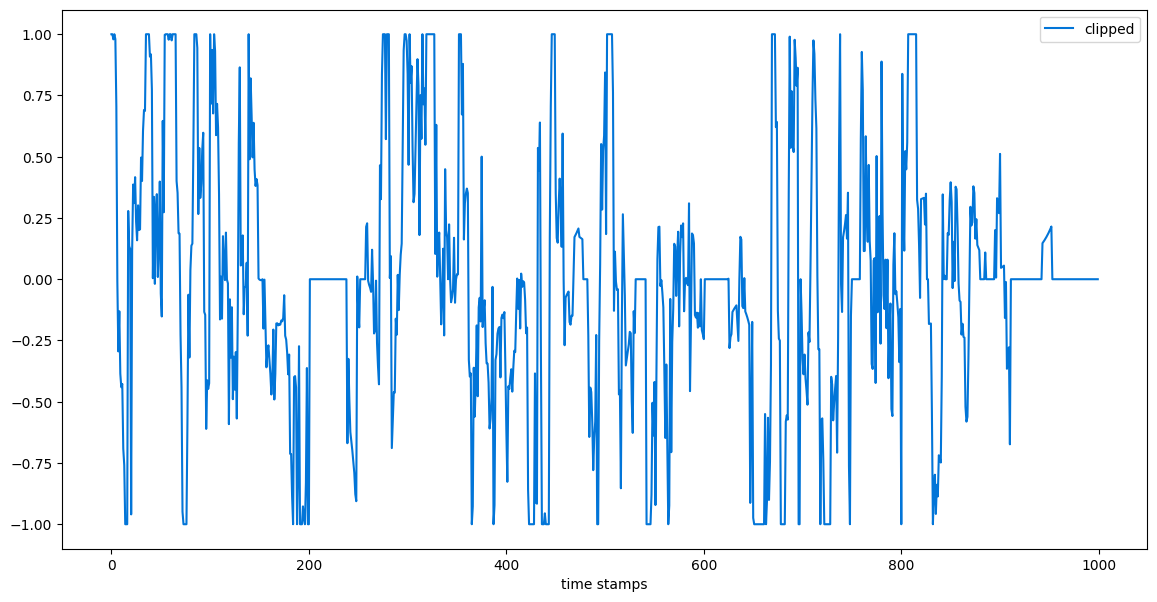

In [29]:
median = np.median(vwap_diff)
q10, q90 = np.percentile(vwap_diff, [10, 90])
iqr = q90 - q10

robust_scaling = (vwap_diff - median)/(iqr + 1e-8)
clipped = np.clip(robust_scaling, -1.0, 1.0)
plot_xy(
    series_list=[
        {"y": clipped, "label": "clipped"},
    ],
    index=1000,
    title="vwap difference"

)


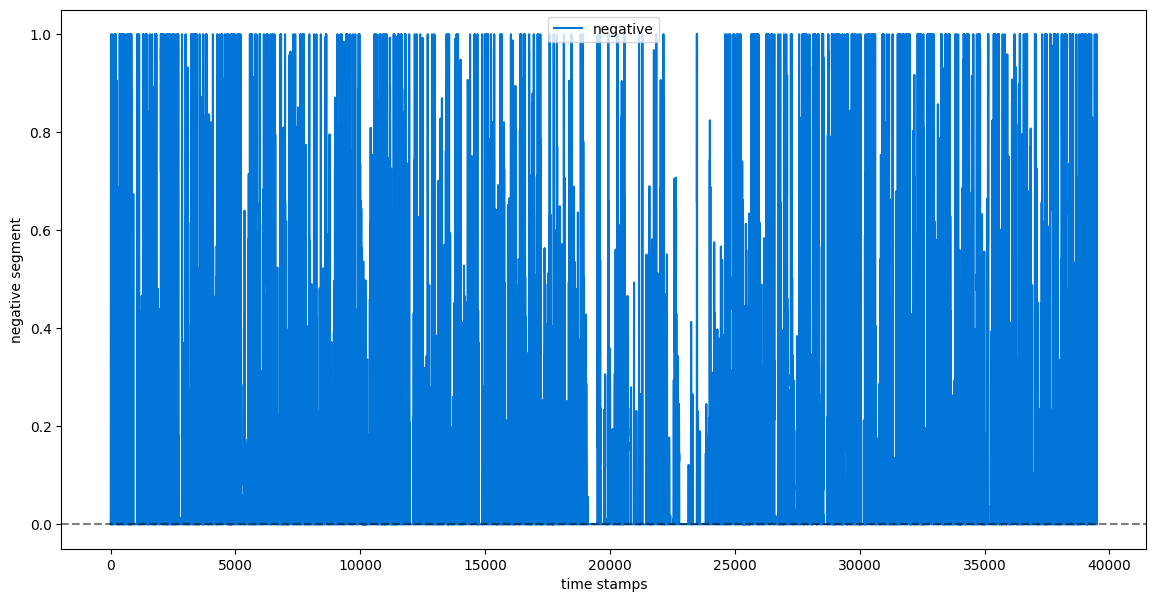

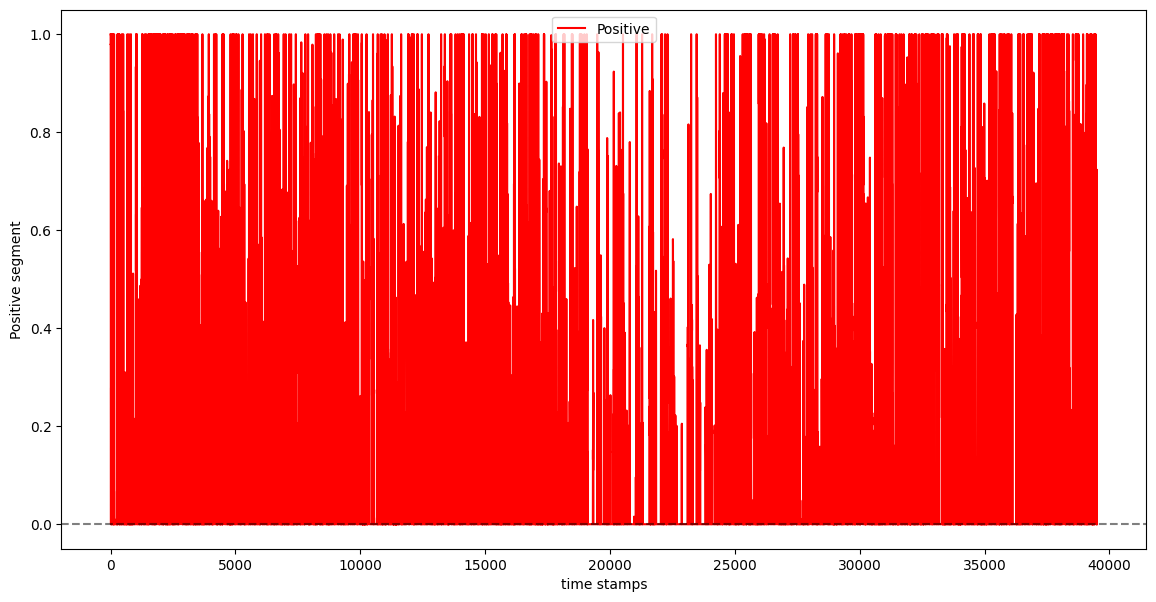

In [30]:
# seperates the VWAP into 2 arrays (positive and negative)
positive_channel = np.where(clipped > 0, clipped, 0.0)
negative_channel = np.where(clipped < 0, np.abs(clipped), 0.0)
plot_xy(
    series_list=[
        {"y": negative_channel, "label": "negative"},
    ],
    index=time_steps,
    title="NEGATIVE",
    ylabel="negative segment",
    axhline=0,
)
plot_xy(
    series_list=[
        {"y": positive_channel, "label": "Positive", "color": "red"},
    ],
    index=time_steps,
    title="Positive",
    ylabel="Positive segment",
    axhline=0,
)


In [31]:
#CUSTOM Min-Max instead of the sklearn one
scaled_positive = (positive_channel - positive_channel.mean()) / (positive_channel.max() - positive_channel.min() + 1e-8)
scaled_negative = (negative_channel - negative_channel.mean()) / (negative_channel.max() - negative_channel.min() + 1e-8)

scaled_negative[negative_channel == 0.0] = 0.0
scaled_positive[positive_channel == 0.0] = 0.0

In [32]:
## Encoding
def poisson_encoding(inputs):
    inputs = np.asarray(inputs)
    spike_train = np.zeros_like(inputs)
    for t in range(len(inputs)):
        if random.random() < inputs[t]:
            spike_train[t] = 1.0
    return spike_train


p = poisson_encoding(scaled_positive)
n = poisson_encoding(scaled_negative)
            
        
print(n)

[0. 0. 0. ... 0. 0. 1.]


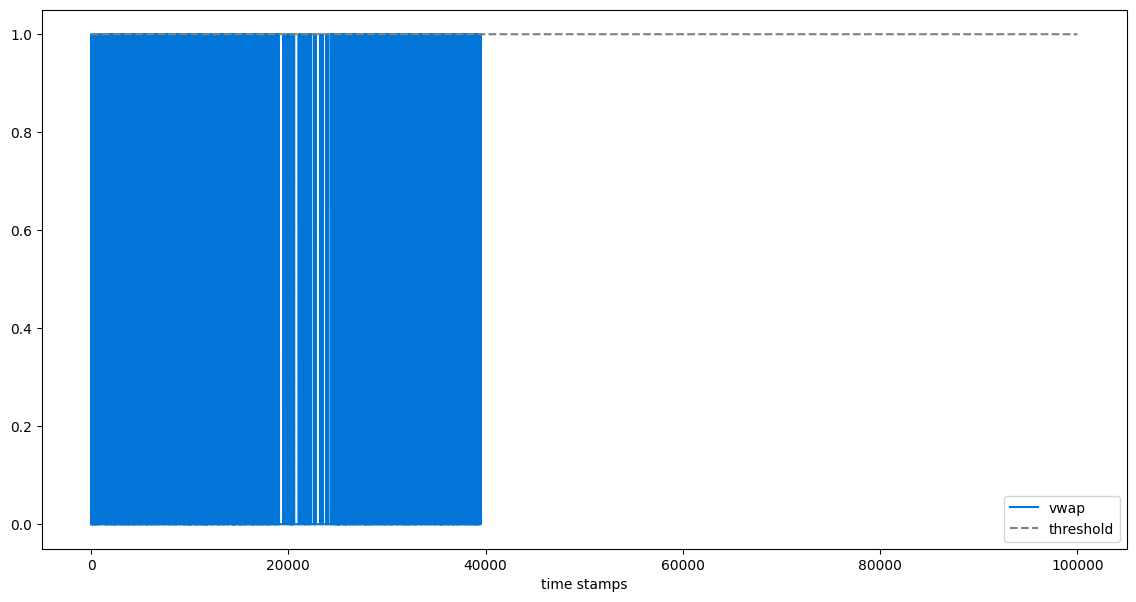

In [33]:
plot_xy(
   series_list=[
       {"y": n, "label": "vwap"},
       {"y": np.ones(time_steps), "label": "threshold", "linestyle": "dashed","color": "gray"},
   ],
   index=time_steps,
   title="Trend vs MinMaxed",
)
c = 0


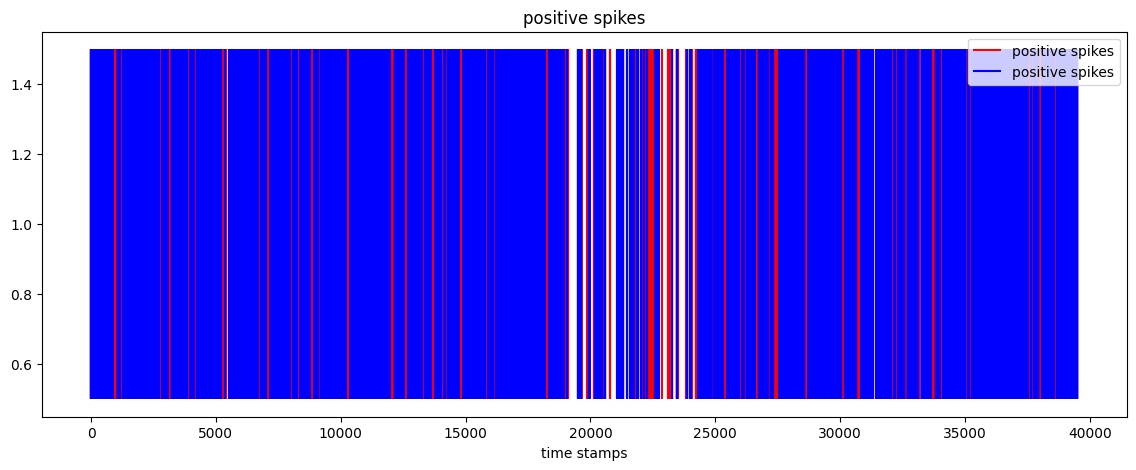

In [34]:

plot_spike(
    series_list=[
        {"y": p, "label": "positive spikes",},
        {"y": n, "label": "positive spikes", "color": "blue"},
    ],
    figsize=(14, 5),
    index=time_steps,
    title="positive spikes"
) 

In [57]:
%pip install torch torchvision torchaudio

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/4.2 MB ? eta -:--:--
   ----------------- ---------------------- 1.8/4.2 MB 16.7 MB/s eta 0:00:01
   ---------------------------------------- 4.2/4.2 MB 13.8 MB/s  0:00:00
   ---------------------------------------- 0.0/123.0 MB ? eta -:--:--
   - -------------------------------------- 5.8/123.0 MB 28.3 MB/s eta 0:00:05
   --- ------------------------------------ 11.5/123.0 MB 27.7 MB/s eta 0:00:05
   ----- ---------------------------------- 17.3/123.0 MB 27.6 MB/s eta 0:00:04
   ------- -------------------------------- 22.8/123.0 MB 27.5 MB/s eta 0:00:04
   --------- ------------------------------ 28.6/123.0 MB 27.5 MB/s eta 0:00:04
   ----------- ---------------------------- 34.6/123.0 MB 27.4 MB/s eta 0:00:04
   ------------- -------------------------- 40.4/123.0 MB 27.4 MB/s eta 0:00:04
   -------------- ------------------------- 45.4/123.0 MB 27.1 MB/s eta 